# **Deep Learning: Image Classification using CNN and Transfer Learning**

Libraries:

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## **1. Data Loading, Preprocessing, and Visualization**

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step


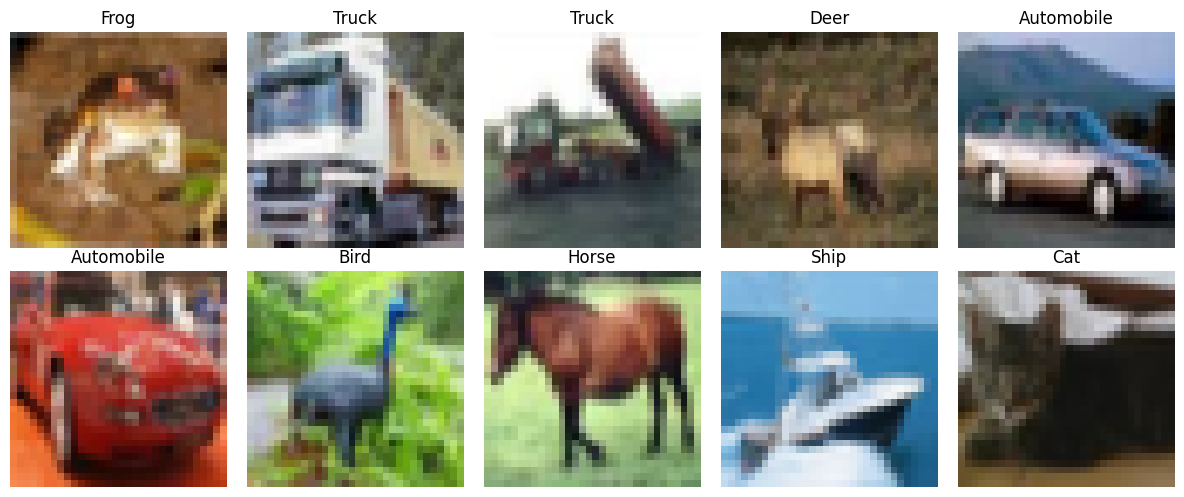

{'Airplane': np.int64(5000),
 'Automobile': np.int64(5000),
 'Bird': np.int64(5000),
 'Cat': np.int64(5000),
 'Deer': np.int64(5000),
 'Dog': np.int64(5000),
 'Frog': np.int64(5000),
 'Horse': np.int64(5000),
 'Ship': np.int64(5000),
 'Truck': np.int64(5000)}

In [3]:
# Data Load 
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

#Class names for CIFAR-10
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(class_names[y_train[i][0]])
    ax.axis('off')
plt.tight_layout()
plt.show()

# Check class distribution
unique, counts = np.unique(y_train, return_counts=True)
dict(zip(class_names, counts))

In [ ]:
# Normalize to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# 3. Data Augmentation Pipeline (Modern Best Practice)
# It can be embedded directly into the networks
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),])

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


## **2. Custom CNN**

Building a CNN architecture, using Batch Normalization and Dropout to prevent overfitting:

In [5]:
def build_custom_cnn():
    model = models.Sequential([
        
        # Input layer & Augmentation
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,
        
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Classifier Head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax') # 10 classes
    ])
    return model

custom_cnn = build_custom_cnn()
custom_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 358,218 (1.37 MB)

 Trainable params: 357,514 (1.36 MB)

 Non-trainable params: 704 (2.75 KB)

## **3. Train and Evaluate the Custom CNN**

TRains and evaluate the custom CNN with standard callbacks to stop training if the model stops improving:

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.3805 - loss: 1.8095 - val_accuracy: 0.4628 - val_loss: 1.4980 - learning_rate: 0.0010
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4957 - loss: 1.4060 - val_accuracy: 0.5167 - val_loss: 1.4492 - learning_rate: 0.0010
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5390 - loss: 1.2921 - val_accuracy: 0.6082 - val_loss: 1.1002 - learning_rate: 0.0010
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.5679 - loss: 1.2174 - val_accuracy: 0.5837 - val_loss: 1.2305 - learning_rate: 0.0010
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.5889 - loss: 1.1636 - val_accuracy: 0.5841 - val_loss: 1.2060 - learning_rate: 0.0010
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6028 - loss: 1.1242 - val_accuracy: 0.6561 - val_loss: 0.9783 - learning_rate: 0.0010
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6123 - l

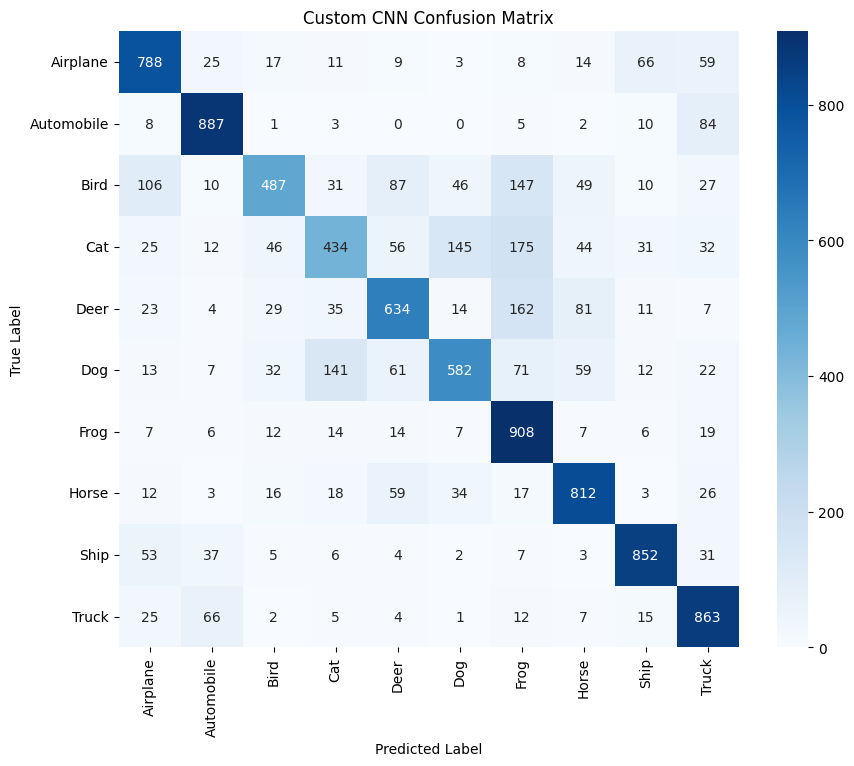

In [6]:
# 1. Compile the model
custom_cnn.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# 2. Define Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# 3. Train the model
history_cnn = custom_cnn.fit(
    X_train, y_train,
    epochs=30, # High number, but EarlyStopping will halt it early if needed
    validation_data=(X_test, y_test),
    batch_size=64,
    callbacks=[early_stopping, reduce_lr])

# 4. Evaluate and plot Confusion Matrix
def evaluate_model(model, X_test, y_test, model_name="Model"):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"{model_name} Test Accuracy: {acc:.4f}")
    
    y_pred = np.argmax(model.predict(X_test), axis=1)
    
    # Classification Report
    print(f"\nClassification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    # Confusion Matrix Heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

evaluate_model(custom_cnn, X_test, y_test, "Custom CNN")

## **4. Transfer Learning (MobileNetV2, EfficientNetB0, ResNet50V2)**

CIFAR-10 images are very small (32x32). Models like EfficientNet or MobileNet prefer larger images, so a Resizing layer will be added to scale the images up to 96x96 before passing them into the pre-trained base.

The idea is to run the three transfer learning models, compare them and get the best one.

In [7]:
def train_pretrained_model(model_name, X_train, y_train, X_test, y_test, epochs=10):
    print(f"\n--- Initializing {model_name} ---")
    
    # Select the Base Model and its specific Preprocessing
    if model_name == 'MobileNetV2':
        base = tf.keras.applications.MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
        # MobileNet expects [-1, 1]
        preprocess = layers.Lambda(lambda x: (x * 2.0) - 1.0) 
        
    elif model_name == 'EfficientNetB0':
        base = tf.keras.applications.EfficientNetB0(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
        # EfficientNet expects [0, 255]
        preprocess = layers.Rescaling(255.0)
        
    elif model_name == 'ResNet50V2':
        base = tf.keras.applications.ResNet50V2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
        # ResNetV2 has its own complex scaling utility
        preprocess = layers.Lambda(lambda x: tf.keras.applications.resnet_v2.preprocess_input(x * 255.0))
    
    base.trainable = False # Freeze the "brain"

    # Full pipeline
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Resizing(96, 96),
        preprocess,
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    # Compile
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train
    history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test), batch_size=64)
    
    return model, history

# Run all three experiments one after another
model_mobile, history_mobile = train_pretrained_model('MobileNetV2', X_train, y_train, X_test, y_test)
model_eff, history_eff = train_pretrained_model('EfficientNetB0', X_train, y_train, X_test, y_test)
model_res, history_res = train_pretrained_model('ResNet50V2', X_train, y_train, X_test, y_test)


--- Initializing MobileNetV2 ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.7736 - loss: 0.6787 - val_accuracy: 0.8450 - val_loss: 0.4440
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8369 - loss: 0.4802 - val_accuracy: 0.8496 - val_loss: 0.4307
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8456 - loss: 0.4545 - val_accuracy: 0.8545 - val_loss: 0.4236
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8482 - loss: 0.4402 - val_accuracy: 0.8611 - val_loss: 0.3995
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8514 - loss: 0.4345 - val_accuracy: 0.8595 - val_loss: 0.4041
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8487 - loss: 0.4382 - val_accuracy: 0.8552 - val_loss: 0.4181
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8519 - loss: 0.4343 - val_accuracy: 0.8581 - val_loss: 0.4061
Epoch 8

## **5. Comparison Plots & Best Model**

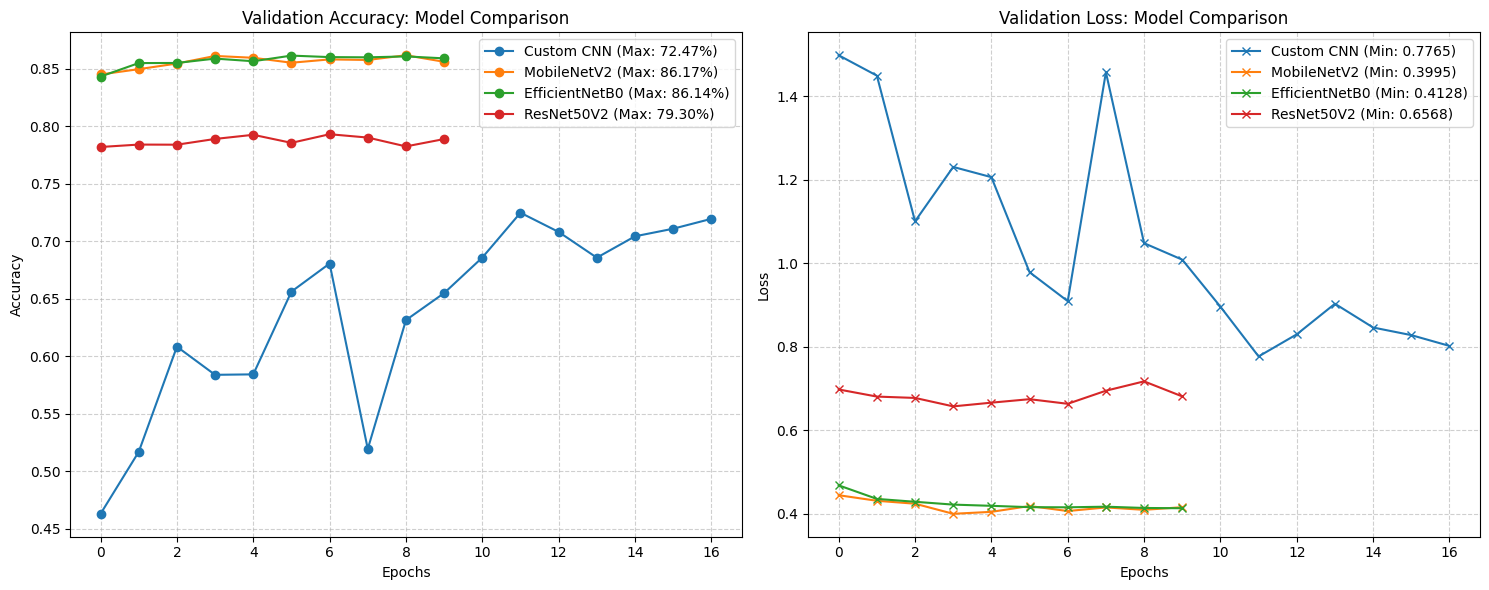


Performance Summary
Custom CNN     : 72.47% Validation Accuracy
MobileNetV2    : 86.17% Validation Accuracy
EfficientNetB0 : 86.14% Validation Accuracy
ResNet50V2     : 79.30% Validation Accuracy
The best model is: MobileNetV2 with 86.17% accuracy


In [8]:
def analyze_and_select_best(models_dict:dict , histories_dict: dict):
    """
    Graphs the results of all models and prints the winner.
    Args:
        models_dict: {'ModelName': model_object}
        histories_dict: {'ModelName': history_object}
    """
    plt.figure(figsize=(15, 6))
    
    # 1. Plot Validation Accuracy Comparison
    plt.subplot(1, 2, 1)
    for name, history in histories_dict.items():
        val_acc = history.history['val_accuracy']
        plt.plot(val_acc, label=f'{name} (Max: {max(val_acc):.2%})', marker='o')
    
    plt.title('Validation Accuracy: Model Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # 2. Plot Validation Loss Comparison
    plt.subplot(1, 2, 2)
    for name, history in histories_dict.items():
        val_loss = history.history['val_loss']
        plt.plot(val_loss, label=f'{name} (Min: {min(val_loss):.4f})', marker='x')
        
    plt.title('Validation Loss: Model Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

    # 3. Logic to choose the winner
    best_name = None
    best_val_acc = 0
    
    print("\n" + "="*30)
    print("Performance Summary")
    print("="*30)
    
    for name, history in histories_dict.items():
        final_acc = max(history.history['val_accuracy'])
        print(f"{name.ljust(15)}: {final_acc:.2%} Validation Accuracy")
        
        if final_acc > best_val_acc:
            best_val_acc = final_acc
            best_name = name
            
    print("="*30)
    print(f"The best model is: {best_name} with {best_val_acc:.2%} accuracy")
    print("="*30)
    
    # Save the winner
    best_model = models_dict[best_name]
    best_model.save(f"best_model_{best_name.lower()}.keras")


# Analysis
# Dictionaries to pass into the function
models_to_compare = {
    'Custom CNN': history_cnn, 
    'MobileNetV2': history_mobile,
    'EfficientNetB0': history_eff,
    'ResNet50V2': history_res}

models_objects = {
    'Custom CNN': custom_cnn,
    'MobileNetV2': model_mobile,
    'EfficientNetB0': model_eff,
    'ResNet50V2': model_res}

analyze_and_select_best(models_objects, models_to_compare)

## **6. Ensemble**

In [ ]:
from sklearn.metrics import accuracy_score

def evaluate_ensemble(models_list, X_test, y_test, class_names):
    print("Soft Voting predictions from all models:")
    
    # List to store raw probability arrays from each model
    all_probabilities = []
    
    for i, model in enumerate(models_list):
        print(f"   -> Predicting with Model {i+1}...")
        # Get the raw probability scores (the softmax output)
        probs = model.predict(X_test, verbose=0)
        all_probabilities.append(probs)
        
    # Average the probabilities across all models (Soft Voting)
    ensemble_avg_probs = np.mean(all_probabilities, axis=0)
    
    # Get the final class prediction (the one with the highest average probability)
    ensemble_final_classes = np.argmax(ensemble_avg_probs, axis=1)
    
    # Calculate Final Accuracy
    ensemble_acc = accuracy_score(y_test, ensemble_final_classes)
    
    print("\n" + "="*40)
    print(f"ENSEMBLE VALIDATION ACCURACY: {ensemble_acc:.2%}")  
    print("="*40)
    
    return ensemble_final_classes

# Combine your two best models to form a "Super Model"
top_models = [model_eff, model_mobile] 
ensemble_preds = evaluate_ensemble(top_models, X_test, y_test, class_names)

# Print the new classification report
print("\nEnsemble Classification Report:\n")
print(classification_report(y_test, ensemble_preds, target_names=class_names))

Soft Voting predictions from all models:
   -> Predicting with Model 1...
   -> Predicting with Model 2...

ENSEMBLE VALIDATION ACCURACY: 89.34%

Ensemble Classification Report:

              precision    recall  f1-score   support

    Airplane       0.88      0.93      0.90      1000
  Automobile       0.94      0.96      0.95      1000
        Bird       0.92      0.83      0.87      1000
         Cat       0.78      0.80      0.79      1000
        Deer       0.87      0.88      0.88      1000
         Dog       0.87      0.81      0.84      1000
        Frog       0.91      0.94      0.92      1000
       Horse       0.89      0.93      0.91      1000
        Ship       0.94      0.93      0.94      1000
       Truck       0.93      0.93      0.93      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

